[Home](../../README.md)

### Model Evaluation

This is a demonstration of evaluating a model.

#### Step 1

Load the required dependencies.


In [1]:
# Import frameworks
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use('../../style_Matplotlib_charts.mplstyle')
from sklearn.linear_model import LinearRegression
import pickle

####  Step 2

Load the model for testing

In [2]:
filename = 'my_saved_model_v1.sav'
model_A = pickle.load(open(filename, 'rb'))


(Optional) Load a second model if you want to do comparative testing

In [3]:
filename = 'my_saved_model_v1.sav'
model_B = pickle.load(open(filename, 'rb'))

####  Step 3
Open and parse the test data CSV file and store the data as variable array data objects.

In [4]:
x_col = 'BMI'
testing_data = pd.read_csv('2.4.1.testing_data.csv')
x_test = np.array(testing_data[x_col]).reshape(-1,1)
y_test = np.array(testing_data['Target'])

#### Step 5

Plot the test data features, targets and linear regression model to visually evaluate the model.

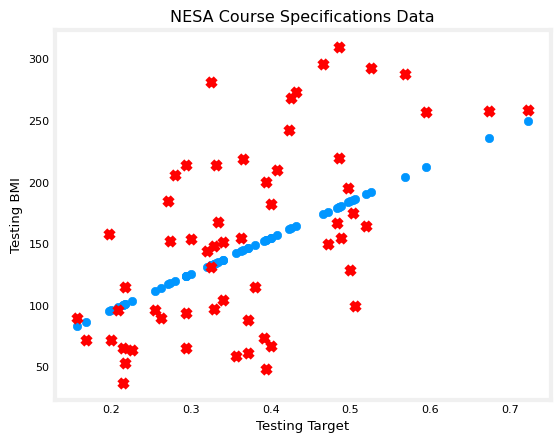

In [5]:
y_pred = model_A.predict(x_test)
plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

#### Step 6

Use the 'score' method of the `LinearRegression` class to return a score based evaluation of the models accuracy or performance.

In [6]:
test_score = model_A.score(x_test, y_test)
print(f'Training data score: {test_score}')

Training data score: 0.3265836228499944


#### Step 7

Manually calculate and evaluate the 'loss' and 'cost' of the model using the test data.

In [7]:
table = pd.DataFrame({
    testing_data.columns[0]: x_test.flatten(),  # Flatten x for easy display
    testing_data.columns[1]: y_test,
    'Predicted result':model_A.predict(x_test),
    'Loss' : abs(model_A.predict(x_test).round(2) - y_test)**2
})
print(table)
cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()

print(f"The cost or average loss of this model is {cost}")

         DoB    DoT  Predicted result        Loss
0   0.425714  268.0        162.410942  11149.2481
1   0.394286   48.0        153.136523  11054.4196
2   0.157143   90.0         83.156816     46.7856
3   0.371429   61.0        146.391491   7291.4521
4   0.365714  219.0        144.705233   5519.0041
5   0.262857   90.0        114.352589    592.9225
6   0.294286  214.0        123.627008   8166.7369
7   0.482857  167.0        179.273522    150.5529
8   0.225714   64.0        103.391912   1551.5721
9   0.168571   72.0         86.529332    211.1209
10  0.594286  257.0        212.155552   2010.6256
11  0.214286   65.0        100.019396   1226.4004
12  0.274286  152.0        117.725105   1174.4329
13  0.520000  164.0        190.234198    688.0129
14  0.294286   65.0        123.627008   3437.4769
15  0.331429  214.0        134.587685   6305.9481
16  0.217143  115.0        100.862525    199.9396
17  0.497143  195.0        183.489167    132.4801
18  0.471429  150.0        175.901006    670.8100


You may want to do some manual predictions to understand your model.

In [8]:
print(model_A.predict([[0.1]]))
print(model_A.predict([[1]]))

[66.29423636]
[331.87986948]


#### Step 8

Evaluate the X axis intercept and gradient or coefficient of your model by using the getter methods to return the intercept and coefficient from my_model() object.

In [9]:
print(f'X Axis intercept: {model_A.intercept_}')
print(f'Coefficient: {model_A.coef_}')

X Axis intercept: 36.78472156417236
Coefficient: [295.09514792]


#### Step 9. Multiple Variable Linear Regression

You should be able to understand the code snippets with less guidelines.

In [10]:
filename = 'my_saved_model_v2.sav'
model_C = pickle.load(open(filename, 'rb'))

In [11]:
mx_col = ['BMI','BP','FDR']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

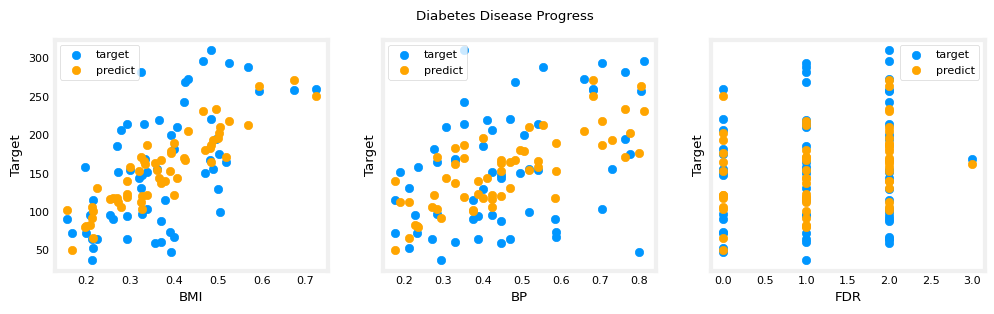

In [12]:
my_pred = model_C.predict(mx_test)

# plot predictions and targets vs original features    
fig,ax=plt.subplots(1,len(mx_col),figsize=(12,3),sharey=True)
for i in range(len(ax)):
    ax[i].scatter(mx_test[:,i],my_test, label = 'target')
    ax[i].set_xlabel(mx_col[i])
    ax[i].scatter(mx_test[:,i],my_pred,color="orange", label = 'predict')
    ax[i].set_ylabel("Target"); ax[i].legend();
fig.suptitle("Diabetes Disease Progress")
plt.show()

In [13]:
test_score = model_C.score(mx_test, my_test)
print(f'Training data score: {test_score}')

Training data score: 0.33379128709192485


In [14]:
print(model_C.predict([[0.1,0.1,0.1]]))
print(model_C.predict([[1,0.5,1]]))

[24.95123617]
[320.71271408]


In [15]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_C.predict(mx_test)
data['Loss'] = abs(model_C.predict(mx_test).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

The cost or average loss of this model is 1882.8218279661019
         BMI        BP  FDR  Target  Predicted result        Loss
0   0.425714  0.482353  1.0   268.0        167.428480  10114.3249
1   0.394286  0.800000  0.0    48.0        176.096946  16409.6100
2   0.157143  0.376471  2.0    90.0        102.454798    155.0025
3   0.371429  0.329412  1.0    61.0        136.668220   5725.9489
4   0.365714  0.411765  1.0   219.0        144.019651   5622.0004
5   0.262857  0.584353  0.0    90.0        118.256683    798.6276
6   0.294286  0.352941  1.0   214.0        118.863557   9051.6196
7   0.482857  0.329412  2.0   167.0        183.254018    264.0625
8   0.225714  0.470588  2.0    64.0        130.653910   4442.2225
9   0.168571  0.176471  0.0    72.0         49.531020    504.9009
10  0.594286  0.803882  2.0   257.0        263.660802     44.3556
11  0.214286  0.270588  2.0    65.0        106.129546   1691.6769
12  0.274286  0.188235  2.0   152.0        113.088249   1513.9881
13  0.520000  0

In [16]:
print(f'X Axis intercept: {model_C.intercept_}')
print(f'Coefficient: {model_C.coef_}')

X Axis intercept: -13.886623537164553
Coefficient: [263.60771145 107.55851898  17.21236668]


#### Step 10. Polynomial Linear Regression

You should be able to understand the code snippets with less guidelines.

In [17]:
model_filename = 'my_saved_model_v3.sav'
poly_filename = 'my_saved_poly_v3.pkl'

model_D = pickle.load(open(model_filename, 'rb'))
poly = pickle.load(open(poly_filename, 'rb'))

FileNotFoundError: [Errno 2] No such file or directory: 'my_saved_model_v3.sav'

In [ ]:
mx_col = ['BMI']
testing_data = pd.read_csv('2.4.1.testing_data.csv')
mx_test = np.array(testing_data[mx_col])
my_test = np.array(testing_data['Target'])

In [ ]:
poly_features = poly.fit_transform(mx_test)

In [ ]:
y_pred = model_D.predict(poly_features)

plt.scatter(x_test, y_pred)
plt.scatter(x_test, y_test, marker='x', c='r')
plt.title("NESA Course Specifications Data")
plt.ylabel(f'Testing {x_col}')
plt.xlabel(f'Testing Target')
plt.show()

In [ ]:
test_score = model_D.score(poly_features, my_test)
print(f'Training data score: {test_score}')

In [ ]:
new_poly_feature = poly.fit_transform([[0.1]])
print(model_D.predict(new_poly_feature))

In [ ]:
data = {col: mx_test[:, i] for i, col in enumerate(mx_col)}
data['Target'] = my_test
data['Predicted result'] = model_D.predict(poly_features)
data['Loss'] = abs(model_D.predict(poly_features).round(2) - my_test)**2
table = pd.DataFrame(data)

cost = 1 / (2 * table.shape[0]) * table['Loss'].sum()
print(f"The cost or average loss of this model is {cost}")

print(table)

#### Step 11

When your model is ready for operations, move it to the [3.Operations\3.1.Deploy_Model](\3.Operations\3.1.Deploy_Model) folder.